<a href="https://colab.research.google.com/github/deepanshuchauhanx1/AI-Traffic-Flow-Optimizer/blob/main/notebooks/03_traffic_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

!pip install ultralytics supervision --quiet
import ultralytics
print("Ultralytics version:", ultralytics.__version__)

Ultralytics version: 8.4.30


In [14]:
from google.colab import drive
drive.mount('/content/drive')

# ─── UPDATE THIS PATH to where your best.pt is saved in Drive ───
BEST_PT_PATH = "/content/drive/MyDrive/best.pt"

import os
if os.path.exists(BEST_PT_PATH):
    print(f"✅ Found best.pt at: {BEST_PT_PATH}")
else:
    print(f"❌ NOT found: {BEST_PT_PATH}")
    print("   → Update BEST_PT_PATH above to the correct location")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found best.pt at: /content/drive/MyDrive/best.pt


In [15]:
from ultralytics import YOLO

# Stage 1: generic vehicle detector (downloads automatically ~6MB)
print("Loading detector...")
detector = YOLO("yolov8n.pt")

# Stage 2: your emergency vehicle classifier
print("Loading your classifier...")
classifier = YOLO(BEST_PT_PATH)

print("\n✅ Classifier classes:")
for idx, name in classifier.names.items():
    print(f"   [{idx}] {name}")

Loading detector...
Loading your classifier...

✅ Classifier classes:
   [0] TwoWheelers
   [1] ambulance
   [2] auto-rikshaw
   [3] bus
   [4] car
   [5] firetruck
   [6] police vehicle


In [16]:
import cv2
import numpy as np
from IPython.display import display, Image as IPImage
import io

# ─── CONFIG ────────────────────────────────────────────────────────
CLASSIFIER_IMGSZ  = 320          # must match your training imgsz
DETECT_CONF       = 0.35         # detector confidence threshold
EMERGENCY_CLASSES = {"ambulance", "firetruck", "police vehicle"}

# COCO vehicle class IDs (for yolov8n.pt)
VEHICLE_COCO_IDS = {2, 3, 5, 7}  # car, motorcycle, bus, truck

# Colors (BGR)
COLOR_EMERGENCY     = (0,   0,   220)  # red
COLOR_NON_EMERGENCY = (0,   200, 50)   # green

FONT       = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.55
THICKNESS  = 2


# ─── PROCESS ONE FRAME ─────────────────────────────────────────────
def process_frame(frame):
    """Run 2-stage detection + classification on a single frame.
    Returns annotated frame and counts dict.
    """
    h, w = frame.shape[:2]
    counts = {"emergency": 0, "non_emergency": 0, "total": 0}

    # Stage 1 — detect vehicles
    det_results = detector(frame, conf=DETECT_CONF, verbose=False)[0]

    for box in det_results.boxes:
        cls_id = int(box.cls[0])
        if cls_id not in VEHICLE_COCO_IDS:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue  # skip tiny boxes

        # Stage 2 — classify the crop
        crop = frame[y1:y2, x1:x2]
        cls_result = classifier(crop, imgsz=CLASSIFIER_IMGSZ, verbose=False)[0]

        top_idx   = int(cls_result.probs.top1)
        top_label = classifier.names[top_idx]
        top_conf  = float(cls_result.probs.top1conf)

        # Color + count
        if top_label in EMERGENCY_CLASSES:
            color = COLOR_EMERGENCY
            counts["emergency"] += 1
        else:
            color = COLOR_NON_EMERGENCY
            counts["non_emergency"] += 1
        counts["total"] += 1

        # Draw box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, THICKNESS)

        # Label pill
        label_text = f"{top_label} {top_conf:.0%}"
        (tw, th), _ = cv2.getTextSize(label_text, FONT, FONT_SCALE, 1)
        pad = 4
        cv2.rectangle(frame, (x1, y1 - th - 2*pad), (x1 + tw + 2*pad, y1), color, -1)
        cv2.putText(frame, label_text, (x1 + pad, y1 - pad),
                    FONT, FONT_SCALE, (255, 255, 255), 1, cv2.LINE_AA)

    return frame, counts


# ─── DRAW HUD OVERLAY ──────────────────────────────────────────────
def draw_hud(frame, counts, frame_num=None, source_label=""):
    overlay = frame.copy()
    cv2.rectangle(overlay, (8, 8), (280, 118), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.55, frame, 0.45, 0, frame)

    lines = [
        (f"Source       : {source_label}",           (200, 200, 200)),
        (f"Frame        : {frame_num}",               (200, 200, 200)),
        (f"Total        : {counts['total']}",         (220, 220, 220)),
        (f"Emergency    : {counts['emergency']}",     (80,  80,  220)),
        (f"Non-emergency: {counts['non_emergency']}", (50,  200, 80)),
    ]
    for i, (text, color) in enumerate(lines):
        cv2.putText(frame, text, (16, 30 + i*18),
                    FONT, 0.46, color, 1, cv2.LINE_AA)
    return frame


# ─── SHOW FRAME INLINE IN COLAB ────────────────────────────────────
def show_frame(frame, title=""):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, buf = cv2.imencode(".jpg", rgb, [cv2.IMWRITE_JPEG_QUALITY, 90])
    display(IPImage(data=buf.tobytes()))
    if title:
        print(title)


print("✅ Config and helpers loaded.")

✅ Config and helpers loaded.


In [20]:
import time

# ─── SET YOUR VIDEO PATH ───────────────────────────────────────────
VIDEO_PATH   = "/content/drive/MyDrive/131232-749706873.mp4"
OUTPUT_PATH  = "/content/annotated_output.mp4"   # saved in Colab session
PREVIEW_EVERY = 999999   # show 1 frame preview every N frames (keeps notebook fast)
MAX_FRAMES    = 300  # set to None to process the full video

# ──────────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open: {VIDEO_PATH}")

vid_w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
vid_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video: {vid_w}×{vid_h} @ {vid_fps:.1f} fps  |  {total_frames} total frames")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, vid_fps, (vid_w, vid_h))

frame_num  = 0
t0         = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_num += 1
    if MAX_FRAMES and frame_num > MAX_FRAMES:
        break

    # Run pipeline
    frame, counts = process_frame(frame)
    frame = draw_hud(frame, counts, frame_num, source_label="video")

    writer.write(frame)

    # Preview every N frames
    if frame_num % PREVIEW_EVERY == 0:
        elapsed = time.time() - t0
        fps_now = frame_num / elapsed
        print(f"Frame {frame_num}  |  {fps_now:.1f} fps  |  "
              f"Emergency: {counts['emergency']}  Non-emergency: {counts['non_emergency']}")
        show_frame(frame, title=f"Preview — frame {frame_num}")

cap.release()
writer.release()

total_time = time.time() - t0
print(f"\n✅ Done! Processed {frame_num} frames in {total_time:.1f}s")
print(f"   Output saved → {OUTPUT_PATH}")

Video: 1080×1920 @ 29.9 fps  |  550 total frames

✅ Done! Processed 301 frames in 25.4s
   Output saved → /content/annotated_output.mp4


In [8]:
from google.colab import files
files.download(OUTPUT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Option B — Run on a WEBCAM snapshot (Colab JavaScript capture)


In [11]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def capture_from_webcam():
    """Opens browser camera via JavaScript, returns a BGR numpy frame."""
    js = Javascript('''
        async function capturePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            const canvas = document.createElement('canvas');

            button.textContent = '📷 Capture';
            button.style.cssText = 'margin:8px;padding:8px 20px;font-size:16px;cursor:pointer;background:#1a73e8;color:#fff;border:none;border-radius:6px;';
            div.appendChild(video);
            div.appendChild(document.createElement('br'));
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            // Wait for button click
            await new Promise(resolve => button.addEventListener('click', resolve));

            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(t => t.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', 0.9);
        }
        capturePhoto();
    ''')
    display(js)
    data_url = eval_js('capturePhoto()')
    # decode base64 → numpy
    header, encoded = data_url.split(',', 1)
    img_bytes = b64decode(encoded)
    img_arr   = np.frombuffer(img_bytes, dtype=np.uint8)
    frame     = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
    return frame


print("Opening your camera — click the Capture button when ready...")
frame = capture_from_webcam()
print(f"✅ Captured frame: {frame.shape[1]}×{frame.shape[0]} px")

# Run pipeline
annotated, counts = process_frame(frame)
annotated = draw_hud(annotated, counts, frame_num=1, source_label="webcam")

print(f"\nResults:")
print(f"  Total vehicles   : {counts['total']}")
print(f"  Emergency        : {counts['emergency']}")
print(f"  Non-emergency    : {counts['non_emergency']}")

show_frame(annotated, title="Webcam capture — annotated")

# Save result
cv2.imwrite("/content/webcam_annotated.jpg", annotated)
print("Saved → /content/webcam_annotated.jpg")

Opening your camera — click the Capture button when ready...


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

### Run pipeline on multiple webcam captures in a loop

In [ ]:
# ─── CONFIG ───────────────────────────────────────────────────────
NUM_CAPTURES = 5      # how many snapshots to take
SAVE_DIR     = "/content/webcam_captures"
# ──────────────────────────────────────────────────────────────────

import os
os.makedirs(SAVE_DIR, exist_ok=True)

for i in range(1, NUM_CAPTURES + 1):
    print(f"\n--- Capture {i} of {NUM_CAPTURES} ---")
    frame = capture_from_webcam()

    annotated, counts = process_frame(frame)
    annotated = draw_hud(annotated, counts, frame_num=i, source_label="webcam")

    save_path = f"{SAVE_DIR}/capture_{i:03d}.jpg"
    cv2.imwrite(save_path, annotated)

    print(f"Emergency: {counts['emergency']}  |  Non-emergency: {counts['non_emergency']}  |  Saved → {save_path}")
    show_frame(annotated)

print(f"\n✅ All {NUM_CAPTURES} captures saved to {SAVE_DIR}/")

---
## Option C — Run on a single test image (quick test)
> Useful for verifying the pipeline before running on full video.

Image: 244×148 px
Total: 1  |  Emergency: 1  |  Non-emergency: 0


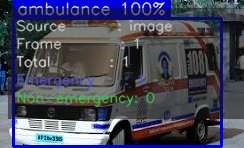

Saved → /content/test_annotated.jpg


In [12]:
# ─── SET IMAGE PATH ───────────────────────────────────────────────
IMAGE_PATH = "/content/drive/MyDrive/download.jpeg"
# ─────────────────────────────────────────────────────────────────

frame = cv2.imread(IMAGE_PATH)
if frame is None:
    raise FileNotFoundError(f"Cannot read: {IMAGE_PATH}")

print(f"Image: {frame.shape[1]}×{frame.shape[0]} px")

annotated, counts = process_frame(frame)
annotated = draw_hud(annotated, counts, frame_num=1, source_label="image")

print(f"Total: {counts['total']}  |  Emergency: {counts['emergency']}  |  Non-emergency: {counts['non_emergency']}")
show_frame(annotated)

# Save
cv2.imwrite("/content/drive/MyDrive/test_annotated.jpg", annotated)
print("Saved → /content/test_annotated.jpg")